# Maze Solver — Search Algorithms Project

## Artificial Intelligence

Nicolás Concuá - 23197

---

## Project Description

This project implements and compares different **search algorithms** to solve a maze problem represented as a grid.

The maze is provided as a **128x128 text file** where each cell represents a type of space:

- `0` → free path  
- `1` → wall  
- `2` → start position  
- `3` → goal position  

The objective is to find a path from the **start node** to the **goal node** using several search strategies and evaluate their performance.

---

## Implemented Algorithms

The following algorithms are implemented and compared:

- Breadth-First Search (**BFS**)  
- Depth-First Search (**DFS**)  
- Greedy Best-First Search  
- A* Search  

For informed search algorithms the following heuristics are used:

- **Manhattan Distance**
- **Euclidean Distance**

---

## Evaluation Metrics

Each algorithm will be evaluated using the following metrics:

- Path length
- Number of explored nodes
- Execution time
- Approximate branching factor

---

## Experiment Setup

Each algorithm will be tested under two conditions:

1. Using the **original start position** defined in the maze.
2. Using **random valid starting positions** inside the maze.

This allows analysis of how algorithm performance changes depending on the distance to the goal.

---

## Notebook Structure

The notebook is organized into the following sections:

1. Maze Loading  
2. Maze Utilities  
3. Node Representation  
4. Search Algorithms  
5. Heuristic Functions  
6. Metrics Collection  
7. Experiment Execution  
8. Results Comparison  

---

## Objective

The goal of this project is to understand the behavior of **uninformed and informed search algorithms**, compare their efficiency, and analyze how heuristics influence performance when solving large maze environments.

In [ ]:
# install standard tools generally used in these assignments (all built-in are python standard except matplotlib)
# %pip install numpy pandas matplotlib

In [30]:
# centralizing imports internally
import time
import math
import heapq
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

In [19]:
# load the text file and convert to integer matrix
def load_maze(file_path):
    maze = []
    # read file lines and parse integers
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            row = [int(char) for char in line.strip() if char.isdigit()]
            if row:
                maze.append(row)
    return maze

In [20]:
# find specific value in grid
def find_position(maze, value):
    for row_idx, row in enumerate(maze):
        for col_idx, cell_value in enumerate(row):
            if cell_value == value:
                return (row_idx, col_idx)
    return None

# define valid moves with UP, RIGHT, DOWN, LEFT priority
# defined as (row_offset, col_offset)
DIRECTIONS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

# generate valid neighbors
def get_neighbors(maze, position):
    row_idx, col_idx = position
    neighbors = []
    
    total_rows = len(maze)
    total_cols = len(maze[0]) if total_rows > 0 else 0
    
    for row_offset, col_offset in DIRECTIONS:
        neighbor_row = row_idx + row_offset
        neighbor_col = col_idx + col_offset
        
        # check if neighbor coordinates are within grid limits
        is_within_bounds = 0 <= neighbor_row < total_rows and 0 <= neighbor_col < total_cols
        
        # check bounds and verify it is not a wall
        if is_within_bounds and maze[neighbor_row][neighbor_col] != 1:
            neighbors.append((neighbor_row, neighbor_col))
            
    return neighbors

In [21]:
class TreeNode:
    def __init__(self, position, path_cost=0, heuristic=0, parent=None):
        self.position = position  # (row, col) tuple
        self.path_cost = path_cost  # g(n)
        self.heuristic = heuristic  # h(n)
        self.parent = parent  # allows path reconstruction
        
    def total_cost(self):
        # f(n) = g(n) + h(n)
        return self.path_cost + self.heuristic

    def __lt__(self, other):
        # tie breaker for priority queues (not strictly defined, but useful)
        return self.total_cost() < other.total_cost()

    def __repr__(self):
        return f"Node({self.position}, g: {self.path_cost}, h: {self.heuristic})"

# extract path to goal
def reconstruct_path(node):
    path = []
    current = node
    while current:
        path.append(current.position)
        current = current.parent
    return path[::-1]  # reverse to start->goal

In [22]:
# standard queue for BFS
class FIFOQueue:
    def __init__(self):
        self.items = []
        
    def is_empty(self):
        return len(self.items) == 0
        
    def push(self, item):
        self.items.append(item)
        
    def pop(self):
        return self.items.pop(0) if not self.is_empty() else None

# basic BFS algorithm
def bfs(maze, start_pos, goal_pos):
    # setup starting node
    start_node = TreeNode(start_pos)
    frontier = FIFOQueue()
    frontier.push(start_node)
    
    # initialize metrics
    explored_nodes = 0
    visited = set()
    start_time = time.time()
    
    while not frontier.is_empty():
        current_node = frontier.pop()
        explored_nodes += 1
        
        # goal check
        if current_node.position == goal_pos:
            exec_time = time.time() - start_time
            path = reconstruct_path(current_node)
            return path, explored_nodes, exec_time
            
        visited.add(current_node.position)
        
        # expand neighbors
        for neighbor_pos in get_neighbors(maze, current_node.position):
            if neighbor_pos not in visited:
                # avoid duplicate pushes
                visited.add(neighbor_pos)
                child = TreeNode(neighbor_pos, path_cost=current_node.path_cost + 1, parent=current_node)
                frontier.push(child)
                
    exec_time = time.time() - start_time
    return None, explored_nodes, exec_time

In [31]:
# standard LIFO stack for DFS
class LIFOQueue:
    def __init__(self):
        self.items = []
        
    def is_empty(self):
        return len(self.items) == 0
        
    def push(self, item):
        self.items.append(item)
        
    def pop(self):
        return self.items.pop() if not self.is_empty() else None

# basic DFS algorithm
def dfs(maze, start_pos, goal_pos):
    # setup starting node
    start_node = TreeNode(start_pos)
    frontier = LIFOQueue()
    frontier.push(start_node)
    
    # initialize metrics
    explored_nodes = 0
    visited = set()
    visited.add(start_pos) # Improvement 1: track before expansion
    start_time = time.time()
    
    while not frontier.is_empty():
        current_node = frontier.pop()
        explored_nodes += 1
        
        # goal check
        if current_node.position == goal_pos:
            exec_time = time.time() - start_time
            path = reconstruct_path(current_node)
            return path, explored_nodes, exec_time
            
        # expand neighbors
        # reversing neighbors to maintain Up, Right, Down, Left priority when popping
        neighbors = get_neighbors(maze, current_node.position)
        for neighbor_pos in reversed(neighbors):
            if neighbor_pos not in visited:
                # Improvement 1: immediately mark visited
                visited.add(neighbor_pos)
                child = TreeNode(neighbor_pos, path_cost=current_node.path_cost + 1, parent=current_node)
                frontier.push(child)
                
    exec_time = time.time() - start_time
    return None, explored_nodes, exec_time

In [24]:
# calculate manhattan distance (|x1 - x2| + |y1 - y2|)
def manhattan_distance(pos1, pos2):
    return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

# calculate straight-line euclidean distance
def euclidean_distance(pos1, pos2):
    return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

In [25]:
# Priority Queue implementation wrapped for Clean Code
class PriorityQueue:
    def __init__(self):
        self.elements = []
        
    def is_empty(self):
        return len(self.elements) == 0
        
    def push(self, item):
        # heapq sorts based on the first tuple value by default
        heapq.heappush(self.elements, item)
        
    def pop(self):
        return heapq.heappop(self.elements) if not self.is_empty() else None

# basic Greedy Search algorithm
def greedy_search(maze, start_pos, goal_pos, heuristic_func):
    start_heuristic = heuristic_func(start_pos, goal_pos)
    start_node = TreeNode(start_pos, heuristic=start_heuristic)
    
    frontier = PriorityQueue()
    # for Greedy we only care about heuristic value
    frontier.push((start_node.heuristic, start_node))
    
    explored_nodes = 0
    visited = set()
    start_time = time.time()
    
    while not frontier.is_empty():
        # pop the node with best heuristic
        current_priority, current_node = frontier.pop()
        explored_nodes += 1
        
        if current_node.position == goal_pos:
            exec_time = time.time() - start_time
            path = reconstruct_path(current_node)
            return path, explored_nodes, exec_time
            
        visited.add(current_node.position)
        
        for neighbor_pos in get_neighbors(maze, current_node.position):
            if neighbor_pos not in visited:
                # avoid duplicate pushes
                visited.add(neighbor_pos)
                h_val = heuristic_func(neighbor_pos, goal_pos)
                child = TreeNode(neighbor_pos, parent=current_node, heuristic=h_val)
                # Greedy sorts strictly by h_val
                frontier.push((h_val, child))
                
    exec_time = time.time() - start_time
    return None, explored_nodes, exec_time

In [26]:
def a_star_search(maze, start_pos, goal_pos, heuristic_func):
    start_heuristic = heuristic_func(start_pos, goal_pos)
    start_node = TreeNode(start_pos, path_cost=0, heuristic=start_heuristic)
    
    frontier = PriorityQueue()
    # A* uses total_cost = g(n) + h(n) as its priority
    frontier.push((start_node.total_cost(), start_node))
    
    explored_nodes = 0
    visited = {} # maps position to best g(n) found so far to prevent expensive re-expansions
    visited[start_pos] = 0
    
    start_time = time.time()
    
    while not frontier.is_empty():
        current_priority, current_node = frontier.pop()
        explored_nodes += 1
        
        # goal check
        if current_node.position == goal_pos:
            exec_time = time.time() - start_time
            path = reconstruct_path(current_node)
            return path, explored_nodes, exec_time
            
        # explore neighbors
        for neighbor_pos in get_neighbors(maze, current_node.position):
            # new g(n) is current g(n) + 1 (cost of moving 1 grid cell)
            new_cost = current_node.path_cost + 1
            
            # if neighbor not visited OR we found a cheaper path to it
            if neighbor_pos not in visited or new_cost < visited[neighbor_pos]:
                visited[neighbor_pos] = new_cost
                
                h_val = heuristic_func(neighbor_pos, goal_pos)
                child = TreeNode(neighbor_pos, path_cost=new_cost, heuristic=h_val, parent=current_node)
                
                # Push based on f(n) = g(n) + h(n)
                frontier.push((child.total_cost(), child))
                
    exec_time = time.time() - start_time
    return None, explored_nodes, exec_time

In [27]:
# wraps execution and computes additional metrics like Branching Factor
def run_and_measure(algorithm_name, maze, start_pos, goal_pos, search_func, *args):
    # Execute the algorithm
    path, explored, exec_time = search_func(maze, start_pos, goal_pos, *args)
    
    path_length = len(path) if path else 0
    
    # approximate branching factor: N = (b^(d+1) - 1) / (b - 1)
    # simplified approximation: root of explored nodes based on depth (path length)
    branching_factor = 0
    if path_length > 1:
        branching_factor = explored ** (1 / path_length)
        
    return {
        "Algorithm": algorithm_name,
        "Path Length": path_length,
        "Explored Nodes": explored,
        "Time (s)": exec_time,
        "Branching Factor (avg)": round(branching_factor, 4)
    }

# function to print a table of results cleanly
def print_comparison_table(results):
    print(f"{'Algorithm':<25} | {'Path Len':<10} | {'Explored':<10} | {'Time(s)':<10} | {'Branching Factor'}")
    print("-" * 80)
    for res in results:
        print(f"{res['Algorithm']:<25} | {res['Path Length']:<10} | {res['Explored Nodes']:<10} | "
              f"{res['Time (s)']:<10.5f} | {res['Branching Factor (avg)']}")

In [32]:
# Scenario 1: Fixed starts from maze definition
def run_scenario_1(maze_file):
    print("--- SCENARIO 1: Fixed Start to Goal ---")
    maze = load_maze(maze_file)
    if not maze:
        print("Failed to load maze.")
        return
        
    start_pos = find_position(maze, 2)
    goal_pos = find_position(maze, 3)
    
    if not start_pos or not goal_pos:
        print("Could not find start (2) or goal (3) in the maze.")
        return
        
    results = []
    
    # BFS
    results.append(run_and_measure("BFS", maze, start_pos, goal_pos, bfs))
    
    # DFS
    results.append(run_and_measure("DFS", maze, start_pos, goal_pos, dfs))
    
    # Greedy (Manhattan)
    results.append(run_and_measure("Greedy (Manhattan)", maze, start_pos, goal_pos, greedy_search, manhattan_distance))
    
    # Greedy (Euclidean)
    results.append(run_and_measure("Greedy (Euclidean)", maze, start_pos, goal_pos, greedy_search, euclidean_distance))
    
    # A* (Manhattan)
    results.append(run_and_measure("A* (Manhattan)", maze, start_pos, goal_pos, a_star_search, manhattan_distance))
    
    # A* (Euclidean)
    results.append(run_and_measure("A* (Euclidean)", maze, start_pos, goal_pos, a_star_search, euclidean_distance))
    
    print_comparison_table(results)

# Improvement 2: utility to generate random valid position with guaranteed path
def generate_random_position(maze, goal_pos):
    total_rows = len(maze)
    total_cols = len(maze[0])
    
    while True:
        r = random.randint(0, total_rows - 1)
        c = random.randint(0, total_cols - 1)
        
        # only proceed if it's an empty path 
        if maze[r][c] == 0:
            start_pos = (r, c)
            # execute a quick bfs to ensure reachability
            path, _, _ = bfs(maze, start_pos, goal_pos)
            if path is not None:
                return start_pos

# Scenario 2: Random valid start
def run_scenario_2(maze_file, num_iterations=1):
    print(f"\n--- SCENARIO 2: Random Starts ({num_iterations} runs) ---")
    maze = load_maze(maze_file)
    goal_pos = find_position(maze, 3)
    
    if not goal_pos:
        print("Could not find goal (3) in the maze.")
        return
        
    for i in range(num_iterations):
        # Improve 2: pass goal pos to guarantee path exists
        random_start = generate_random_position(maze, goal_pos)
        print(f"\nRun {i+1}: Start Pos = {random_start}")
        
        results = []
        results.append(run_and_measure("BFS", maze, random_start, goal_pos, bfs))
        results.append(run_and_measure("DFS", maze, random_start, goal_pos, dfs))
        results.append(run_and_measure("Greedy (Manhattan)", maze, random_start, goal_pos, greedy_search, manhattan_distance))
        results.append(run_and_measure("Greedy (Euclidean)", maze, random_start, goal_pos, greedy_search, euclidean_distance))
        results.append(run_and_measure("A* (Manhattan)", maze, random_start, goal_pos, a_star_search, manhattan_distance))
        results.append(run_and_measure("A* (Euclidean)", maze, random_start, goal_pos, a_star_search, euclidean_distance))
        
        print_comparison_table(results)

In [34]:
# Assume 'test_maze.txt' exists in the very same folder
file_name = 'test_maze.txt'

# Execute fixed start scenario
run_scenario_1(file_name)

# Execute random start scenario (1 time for brevity, can be changed easily)
run_scenario_2(file_name, num_iterations=1)

--- SCENARIO 1: Fixed Start to Goal ---
Algorithm                 | Path Len   | Explored   | Time(s)    | Branching Factor
--------------------------------------------------------------------------------
BFS                       | 129        | 665        | 0.00116    | 1.0517
DFS                       | 129        | 465        | 0.00072    | 1.0488
Greedy (Manhattan)        | 129        | 239        | 0.00048    | 1.0434
Greedy (Euclidean)        | 133        | 402        | 0.00088    | 1.0461
A* (Manhattan)            | 129        | 565        | 0.00150    | 1.0503
A* (Euclidean)            | 129        | 600        | 0.00144    | 1.0508

--- SCENARIO 2: Random Starts (1 runs) ---

Run 1: Start Pos = (27, 29)
Algorithm                 | Path Len   | Explored   | Time(s)    | Branching Factor
--------------------------------------------------------------------------------
BFS                       | 127        | 609        | 0.00088    | 1.0518
DFS                       | 127        

In [33]:
# path visualization helper function
def visualize_solution(maze, path):
    # copy maze to void modifying original references 
    maze_viz = [row[:] for row in maze]
    
    # 0=free(white), 1=wall(black), 2=start(blue), 3=goal(green), 4=path(red)
    if path:
        for r, c in path:
            if maze_viz[r][c] not in (2, 3):
                maze_viz[r][c] = 4
                
    # setup color mapping matching the state numbers 
    cmap = mcolors.ListedColormap(['white', 'black', 'blue', 'green', 'red'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(maze_viz, cmap=cmap, norm=norm)
    
    # hide axes to simulate an exact grid
    plt.xticks([])
    plt.yticks([])
    plt.title("Maze path visualization")
    plt.show()

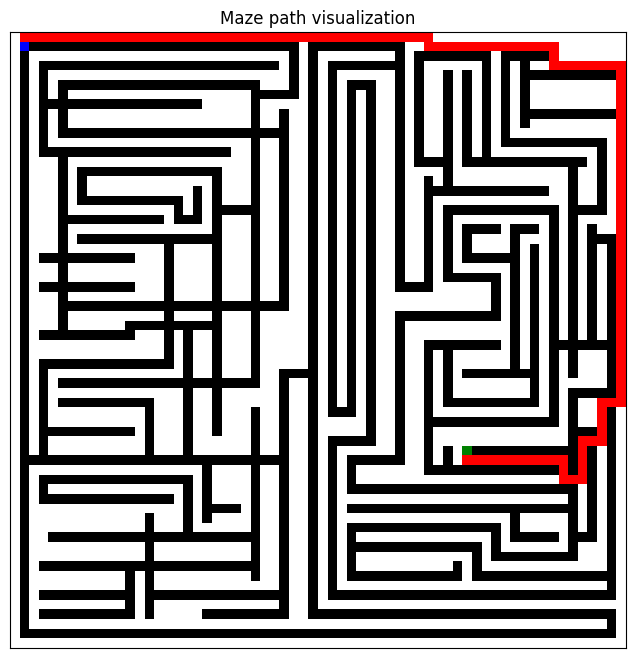

In [35]:
# test visualization logic directly using earlier results mechanics
maze_viz_subject = load_maze('test_maze.txt')
v_start = find_position(maze_viz_subject, 2)
v_goal = find_position(maze_viz_subject, 3)
path_res, _, _ = a_star_search(maze_viz_subject, v_start, v_goal, manhattan_distance)

# Show mapped visualization path of A* Strategy!
if path_res:
    visualize_solution(maze_viz_subject, path_res)